In [1]:
%pip install scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split

In [7]:
import os
print(os.path.expanduser("~"))

/Users/rajpadhi


In [9]:
dataset_path = "/Users/rajpadhi/Desktop/train"

In [11]:
import os

print(os.listdir(dataset_path))

['.DS_Store', 'polymer-non-branded', 'polymer-branded', 'keypad-non-branded', 'others', 'keypad-branded']


In [13]:
classes = [
    "keypad-branded",
    "keypad-non-branded",
    "others",
    "polymer-branded",
    "polymer-non-branded"
]

for split in ["train", "val", "test"]:

    for cls in classes:

        os.makedirs(
            f"processed_dataset/{split}/{cls}",
            exist_ok=True
        )

print("Folders created")

Folders created


In [15]:
split_data = {}

for cls in classes:

    cls_path = os.path.join(
        dataset_path,
        cls
    )

    images = [

        os.path.join(cls_path, img)

        for img in os.listdir(cls_path)

        if img.lower().endswith(
            (".jpg",".jpeg",".png")
        )
    ]

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    split_data[cls] = {
        "train": train_imgs,
        "val": val_imgs,
        "test": test_imgs
    }

print("Dataset split completed")

Dataset split completed


In [17]:
for cls in classes:

    print("\n", cls)

    print(
        "Train:",
        len(split_data[cls]["train"])
    )

    print(
        "Val:",
        len(split_data[cls]["val"])
    )

    print(
        "Test:",
        len(split_data[cls]["test"])
    )


 keypad-branded
Train: 3502
Val: 751
Test: 751

 keypad-non-branded
Train: 3510
Val: 752
Test: 753

 others
Train: 1794
Val: 385
Test: 385

 polymer-branded
Train: 1782
Val: 382
Test: 383

 polymer-non-branded
Train: 1750
Val: 375
Test: 376


In [19]:
sample = split_data[
    "keypad-branded"
]["train"][0]

img = Image.open(sample)

print("Original:", img.size)

Original: (2448, 2048)


(224, 224)


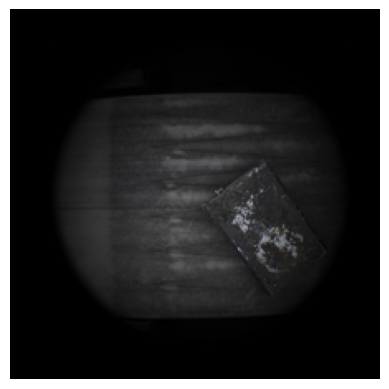

In [21]:
img.thumbnail(
    (224,224),
    Image.Resampling.LANCZOS
)

canvas = Image.new(
    "RGB",
    (224,224),
    (0,0,0)
)

x = (224-img.width)//2
y = (224-img.height)//2

canvas.paste(img,(x,y))

print(canvas.size)

plt.imshow(canvas)
plt.axis("off")
plt.show()

In [23]:
TARGET = (224,224)

for cls in classes:

    for split in ["train","val","test"]:

        image_list = split_data[cls][split]

        print(
            f"\nProcessing {cls} - {split}"
        )

        for img_path in tqdm(image_list):

            try:

                img = Image.open(img_path)

                img.thumbnail(
                    TARGET,
                    Image.Resampling.LANCZOS
                )

                canvas = Image.new(
                    "RGB",
                    TARGET,
                    (0,0,0)
                )

                x = (
                    TARGET[0]-img.width
                )//2

                y = (
                    TARGET[1]-img.height
                )//2

                canvas.paste(img,(x,y))

                filename = os.path.basename(
                    img_path
                )

                save_path = os.path.join(
                    "processed_dataset",
                    split,
                    cls,
                    filename
                )

                canvas.save(save_path)

            except Exception as e:

                print(
                    "Error:",
                    img_path
                )

print("Finished")


Processing keypad-branded - train


100%|███████████████████████████████████████| 3502/3502 [00:58<00:00, 60.14it/s]



Processing keypad-branded - val


100%|█████████████████████████████████████████| 751/751 [00:12<00:00, 60.36it/s]



Processing keypad-branded - test


...


Processing polymer-non-branded - val


100%|█████████████████████████████████████████| 375/375 [00:06<00:00, 57.13it/s]



Processing polymer-non-branded - test


100%|█████████████████████████████████████████| 376/376 [00:06<00:00, 61.30it/s]

Finished


In [25]:
img = Image.open(
    "processed_dataset/train/keypad-branded/"
    +
    os.listdir(
        "processed_dataset/train/keypad-branded"
    )[0]
)

print(img.size)

(224, 224)


In [27]:
records = []

for split in [
    "train",
    "val",
    "test"
]:

    for cls in classes:

        path = os.path.join(
            "processed_dataset",
            split,
            cls
        )

        count = len(os.listdir(path))

        records.append(
            [split, cls, count]
        )

df = pd.DataFrame(
    records,
    columns=[
        "Split",
        "Class",
        "Count"
    ]
)

df

,Split,Class,Count
0,train,keypad-branded,3502
1,train,keypad-non-branded,3510
2,train,others,1794
3,train,polymer-branded,1782
4,train,polymer-non-branded,1750
5,val,keypad-branded,751
6,val,keypad-non-branded,752
7,val,others,385
8,val,polymer-branded,382
9,val,polymer-non-branded,375


In [31]:
records = []

for cls in classes:

    train_count = len(split_data[cls]["train"])
    val_count = len(split_data[cls]["val"])
    test_count = len(split_data[cls]["test"])

    total = train_count + val_count + test_count

    records.append([
        cls,
        train_count,
        val_count,
        test_count,
        total
    ])

df_split = pd.DataFrame(
    records,
    columns=[
        "Class",
        "Train",
        "Val",
        "Test",
        "Total"
    ]
)

df_split

,Class,Train,Val,Test,Total
0,keypad-branded,3502,751,751,5004
1,keypad-non-branded,3510,752,753,5015
2,others,1794,385,385,2564
3,polymer-branded,1782,382,383,2547
4,polymer-non-branded,1750,375,376,2501


In [35]:
total_images = df_split["Total"].sum()

df_split["Percentage"] = (
    df_split["Total"] /
    total_images
) * 100

df_split

,Class,Train,Val,Test,Total,Percentage
0,keypad-branded,3502,751,751,5004,28.381827
1,keypad-non-branded,3510,752,753,5015,28.444218
2,others,1794,385,385,2564,14.542567
3,polymer-branded,1782,382,383,2547,14.446146
4,polymer-non-branded,1750,375,376,2501,14.185242


In [49]:
import os

folders = [
    "figures",
    "tables",
    "models",
    "logs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created")

Project folders created


In [53]:
plt.show()

In [55]:
import os

print(os.listdir())

['Untitled Folder', '.quokka', 'Untitled7.ipynb', 'spam.csc.csv', 'EDA.ipynb', '.config', 'Music', 'f1-race-replay', '.cursor', 'tables', 'Jts', 'fifa_2026_predicter.ipynb', 'credits.csv', '.condarc', '.copilot', 'Untitled5.ipynb', 'Preprocessing.ipynb', 'Untitled1.ipynb', 'java_error_in_pycharm_98061.log', 'spam detection.ipynb', 'TicTacToe Multiplayer Game', '.DS_Store', '.hwid', 'test.ft.txt.bz2.zip', 'untitled1.py', '.vscode-shared', 'fg.py', '.CFUserTextEncoding', '.wallaby', '.xonshrc', 'anaconda_projects', 'Untitled3.ipynb', 'concrete_data.csv', 'Untitled.ipynb', 'heart_disease_data.csv', '.zshrc', 'wingloss-landmark-points-dectection.ipynb', 'Dataset_Audit.ipynb', 'heartdisease.ipynb', 'fifa_ranking-2024-06-20.csv', '.arduinoIDE', 'Untitled4.ipynb', '.local', 'Untitled6.ipynb', '.mongodb', 'jbr_err_pid98061.log', 'projects', 'Pictures', 'fifa_prediction_engine.pkl', '.zprofile', 'node_modules', '.nvm', '.cookiecutters', 'Postman', '.claude', '.zsh_history', 'Untitled2.ipynb', '

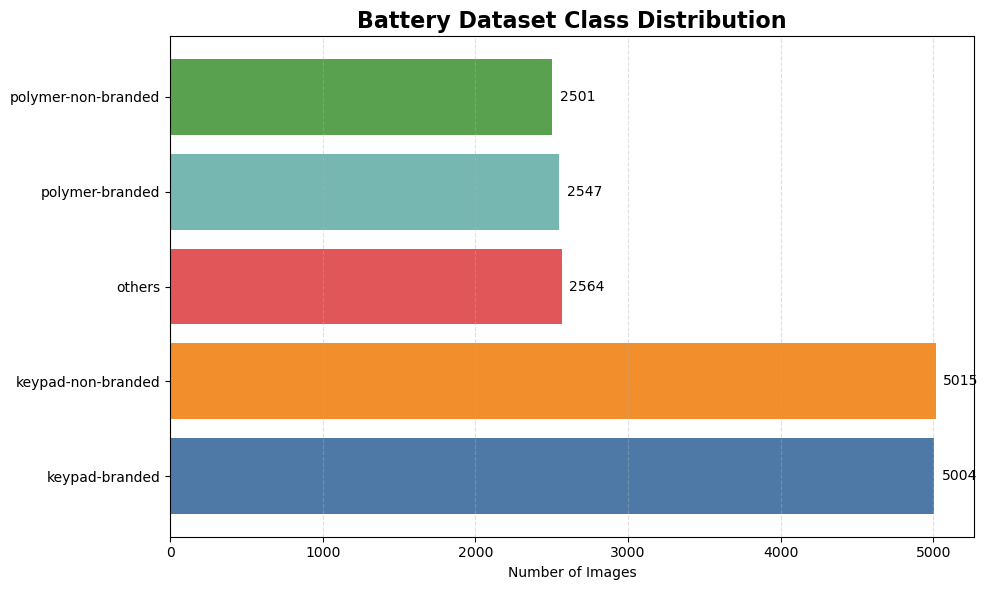

In [57]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    df_split["Class"],
    df_split["Total"],
    color=[
        "#4E79A7",
        "#F28E2B",
        "#E15759",
        "#76B7B2",
        "#59A14F"
    ]
)

for bar in bars:

    plt.text(
        bar.get_width()+50,
        bar.get_y()+bar.get_height()/2,
        f"{int(bar.get_width())}",
        va='center',
        fontsize=10
    )

plt.title(
    "Battery Dataset Class Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Number of Images")
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "figures/class_distribution_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

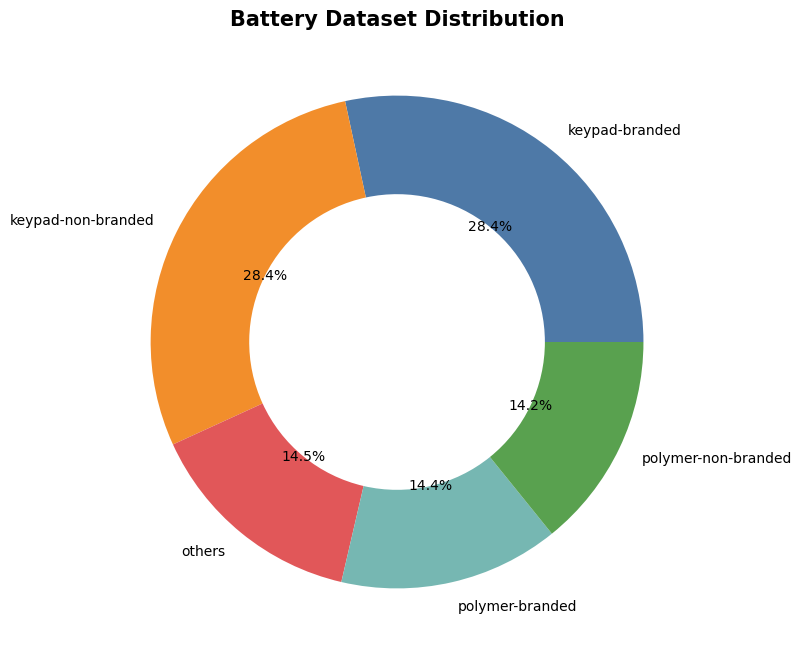

In [59]:
plt.figure(figsize=(8,8))

colors = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F"
]

plt.pie(
    df_split["Total"],
    labels=df_split["Class"],
    autopct="%1.1f%%",
    colors=colors,
    wedgeprops=dict(width=0.4)
)

plt.title(
    "Battery Dataset Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.savefig(
    "figures/donut_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

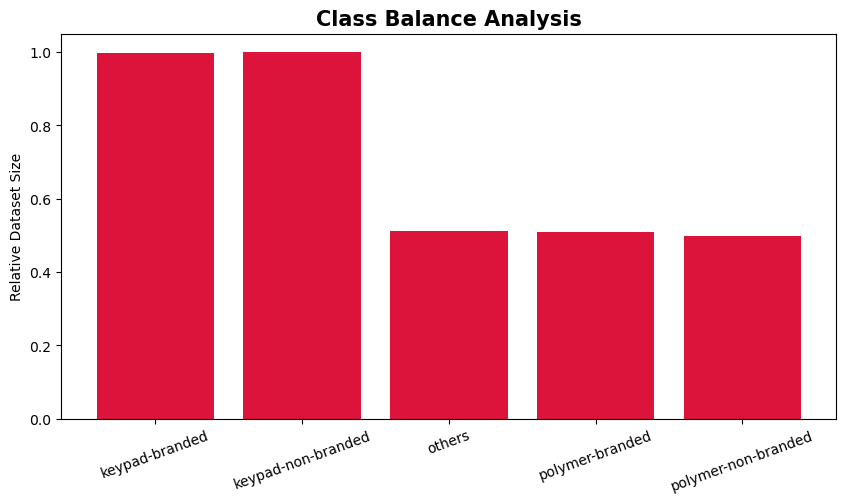

In [61]:
largest = df_split["Total"].max()

df_split["Relative Size"] = (
    df_split["Total"] / largest
)

plt.figure(figsize=(10,5))

plt.bar(
    df_split["Class"],
    df_split["Relative Size"],
    color="crimson"
)

plt.ylabel("Relative Dataset Size")

plt.title(
    "Class Balance Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=20)

plt.savefig(
    "figures/class_balance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

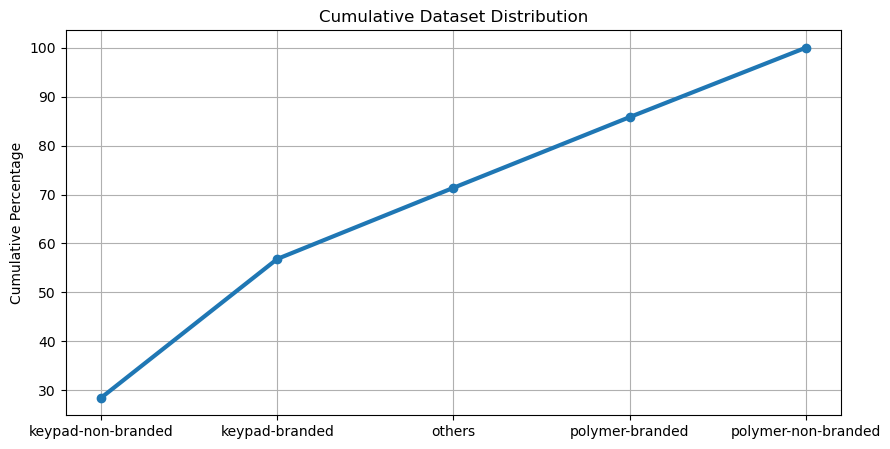

In [63]:
temp = df_split.sort_values(
    "Total",
    ascending=False
)

temp["Cumulative"] = (
    temp["Total"].cumsum()
    /
    temp["Total"].sum()
) * 100

plt.figure(figsize=(10,5))

plt.plot(
    temp["Class"],
    temp["Cumulative"],
    marker="o",
    linewidth=3
)

plt.ylabel("Cumulative Percentage")

plt.title(
    "Cumulative Dataset Distribution"
)

plt.grid(True)

plt.savefig(
    "figures/cumulative_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
%pip install squarify

Note: you may need to restart the kernel to use updated packages.


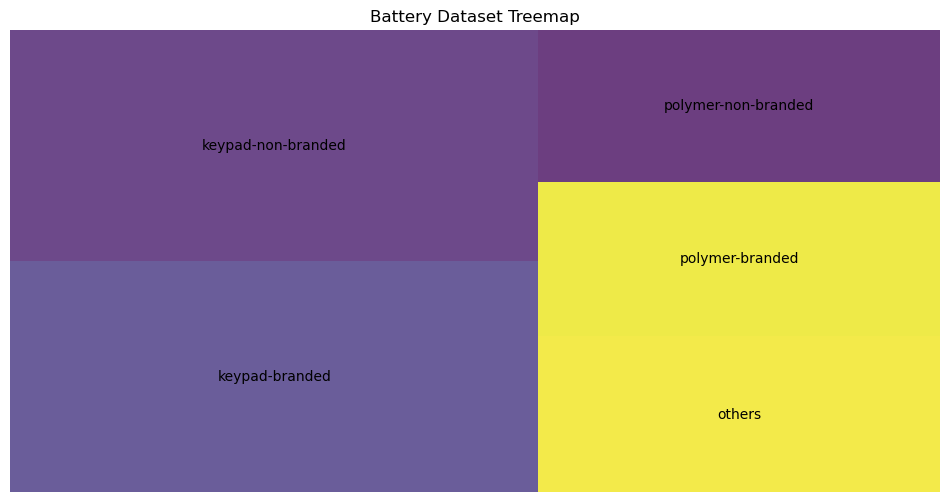

In [69]:
import squarify

plt.figure(figsize=(12,6))

squarify.plot(
    sizes=df_split["Total"],
    label=df_split["Class"],
    alpha=0.8
)

plt.axis("off")

plt.title(
    "Battery Dataset Treemap"
)

plt.savefig(
    "figures/treemap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


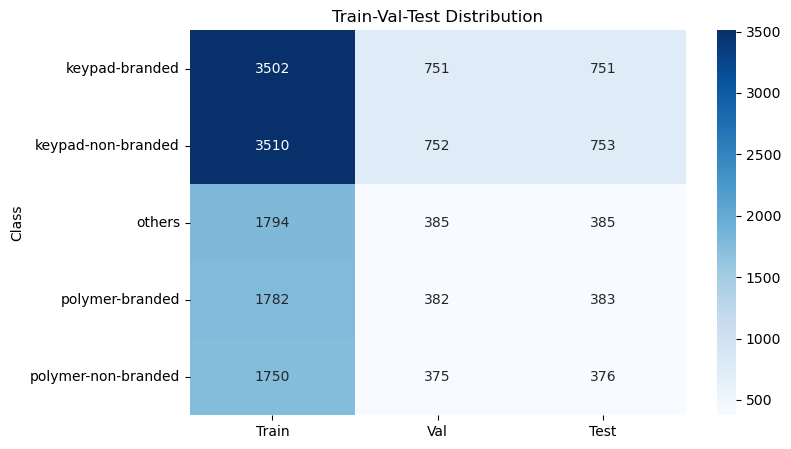

In [73]:
import seaborn as sns

heat_data = df_split.set_index(
    "Class"
)[["Train","Val","Test"]]

plt.figure(figsize=(8,5))

sns.heatmap(
    heat_data,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Train-Val-Test Distribution"
)

plt.savefig(
    "figures/split_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
from PIL import Image
import os
import random

all_images = []

for root, dirs, files in os.walk("processed_dataset"):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            all_images.append(
                os.path.join(root, file)
            )

samples = random.sample(
    all_images,
    min(20, len(all_images))
)

for img_path in samples:

    img = Image.open(img_path)

    print(img.size)

(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)
(224, 224)


In [77]:
from PIL import Image
import os

wrong_size = []

count = 0

for root, dirs, files in os.walk("processed_dataset"):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            path = os.path.join(root, file)

            img = Image.open(path)

            if img.size != (224, 224):

                wrong_size.append(path)

            count += 1

print("Images Checked:", count)
print("Wrong Sized Images:", len(wrong_size))

Images Checked: 17631
Wrong Sized Images: 0


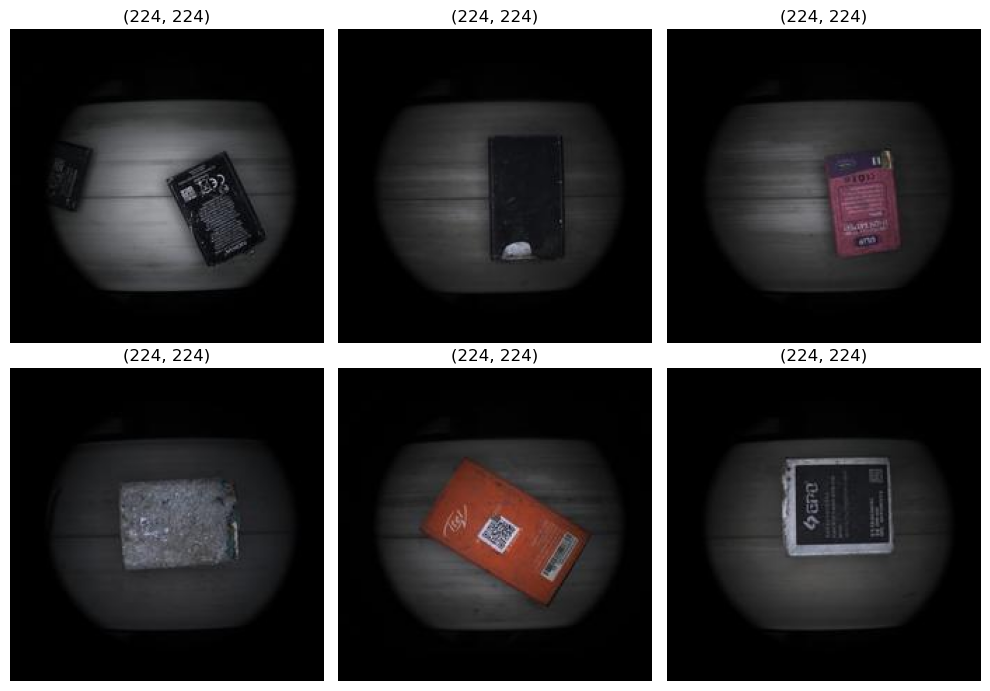

In [80]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

all_images = []

for root, dirs, files in os.walk("processed_dataset"):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            all_images.append(
                os.path.join(root, file)
            )

samples = random.sample(all_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, img_path in zip(axes.flatten(), samples):

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(str(img.size))

    ax.axis("off")

plt.tight_layout()
plt.show()